# Notebook 05 — Model Evaluation
## AI-Powered Customer Feedback Intelligence System

**Purpose:** Evaluate fine-tuned DistilBERT on unseen test data and compare against baseline.

**This notebook:**
- Loads the best saved DistilBERT checkpoint (epoch 2)
- Runs inference on 11,000 unseen test reviews
- Generates full classification metrics
- Compares DistilBERT vs TF-IDF + Logistic Regression
- Produces final visualizations for the Streamlit app

**Rule:** Test set is touched EXACTLY ONCE — right here, right now.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"✅ Imports successful")
print(f"🖥️  Device : {device}")

✅ Imports successful
🖥️  Device : cuda


In [2]:
# ============================================================
# PATHS
# ============================================================

PATHS = {
    'test_data'      : os.path.join('..', 'data', 'processed', 'test.csv'),
    'distilbert_model': os.path.join('..', 'models', 'distilbert', 'best_model'),
    'baseline_tfidf' : os.path.join('..', 'models', 'baseline', 'tfidf_vectorizer.joblib'),
    'baseline_lr'    : os.path.join('..', 'models', 'baseline', 'logistic_regression.joblib'),
    'assets'         : os.path.join('..', 'assets'),
}

# Verify all files exist before proceeding
print("Verifying all model files exist...")
all_exist = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ MISSING"
    print(f"  {name:<20} : {status}  ({path})")
    if not exists:
        all_exist = False

print(f"\n{'✅ All files found — ready to evaluate' if all_exist else '❌ Some files missing — check paths'}")

Verifying all model files exist...
  test_data            : ✅  (..\data\processed\test.csv)
  distilbert_model     : ✅  (..\models\distilbert\best_model)
  baseline_tfidf       : ✅  (..\models\baseline\tfidf_vectorizer.joblib)
  baseline_lr          : ✅  (..\models\baseline\logistic_regression.joblib)
  assets               : ✅  (..\assets)

✅ All files found — ready to evaluate


In [3]:
# ============================================================
# LOAD TEST DATA
# ============================================================

df_test = pd.read_csv(PATHS['test_data'])
df_test['cleaned_text'] = df_test['cleaned_text'].fillna('')

print(f"✅ Test data loaded")
print(f"   Total test reviews : {len(df_test):,}")
print(f"   Positive           : {(df_test['sentiment']==1).sum():,}")
print(f"   Negative           : {(df_test['sentiment']==0).sum():,}")
print(f"\nSample test review:")
print(f"  Text      : {df_test['cleaned_text'].iloc[0][:100]}...")
print(f"  Sentiment : {df_test['sentiment'].iloc[0]} ({df_test['sentiment_label'].iloc[0]})")

✅ Test data loaded
   Total test reviews : 11,000
   Positive           : 5,500
   Negative           : 5,500

Sample test review:
  Text      : In my opinion, this type of olive isn't good for an olive spread. Of course, I had no way of knowing...
  Sentiment : 0 (Negative)


In [4]:
# ============================================================
# EVALUATE BASELINE MODEL ON TEST SET
# ============================================================

print("Loading baseline model...")
tfidf    = joblib.load(PATHS['baseline_tfidf'])
lr_model = joblib.load(PATHS['baseline_lr'])
print("✅ Baseline model loaded\n")

# Transform test data
X_test = df_test['cleaned_text']
y_test = df_test['sentiment']

X_test_tfidf = tfidf.transform(X_test)
y_pred_baseline = lr_model.predict(X_test_tfidf)
y_prob_baseline = lr_model.predict_proba(X_test_tfidf)

# Metrics
baseline_metrics = {
    'accuracy' : accuracy_score(y_test, y_pred_baseline),
    'precision': precision_score(y_test, y_pred_baseline),
    'recall'   : recall_score(y_test, y_pred_baseline),
    'f1'       : f1_score(y_test, y_pred_baseline)
}

print("=" * 55)
print("BASELINE MODEL (TF-IDF + Logistic Regression)")
print("TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy  : {baseline_metrics['accuracy']:.4f}  ({baseline_metrics['accuracy']*100:.2f}%)")
print(f"  Precision : {baseline_metrics['precision']:.4f}")
print(f"  Recall    : {baseline_metrics['recall']:.4f}")
print(f"  F1-Score  : {baseline_metrics['f1']:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline,
      target_names=['Negative', 'Positive']))

Loading baseline model...
✅ Baseline model loaded

BASELINE MODEL (TF-IDF + Logistic Regression)
TEST SET RESULTS
  Accuracy  : 0.9186  (91.86%)
  Precision : 0.9236
  Recall    : 0.9127
  F1-Score  : 0.9182

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.92      0.92      5500
    Positive       0.92      0.91      0.92      5500

    accuracy                           0.92     11000
   macro avg       0.92      0.92      0.92     11000
weighted avg       0.92      0.92      0.92     11000



In [5]:
# ============================================================
# DATASET CLASS FOR DISTILBERT INFERENCE
# ============================================================

class AmazonReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts      = texts.tolist()
        self.labels     = labels.tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label'         : torch.tensor(label, dtype=torch.long)
        }

print("✅ Dataset class defined")

✅ Dataset class defined


In [6]:
# ============================================================
# LOAD DISTILBERT + EVALUATE ON TEST SET
# ============================================================

print("Loading fine-tuned DistilBERT model...")
tokenizer = DistilBertTokenizerFast.from_pretrained(PATHS['distilbert_model'])
model     = DistilBertForSequenceClassification.from_pretrained(PATHS['distilbert_model'])
model     = model.to(device)
model.eval()
print(f"✅ Model loaded and moved to {device}\n")

# Create test dataset and loader
test_dataset = AmazonReviewDataset(
    df_test['cleaned_text'],
    df_test['sentiment'],
    tokenizer,
    max_length=256
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Running inference on {len(test_dataset):,} test reviews...")
print(f"Batch size: 64  |  Batches: {len(test_loader)}")
print("Please wait...\n")

# ── Inference loop ───────────────────────────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Get probabilities using softmax
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if (i + 1) % 20 == 0:
            print(f"  Processed {(i+1)*64:,} / {len(test_dataset):,} reviews...")

all_probs = np.array(all_probs)

# ── Metrics ──────────────────────────────────────────────────
distilbert_metrics = {
    'accuracy' : accuracy_score(all_labels, all_preds),
    'precision': precision_score(all_labels, all_preds),
    'recall'   : recall_score(all_labels, all_preds),
    'f1'       : f1_score(all_labels, all_preds)
}

print("\n" + "=" * 55)
print("FINE-TUNED DISTILBERT")
print("TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy  : {distilbert_metrics['accuracy']:.4f}  ({distilbert_metrics['accuracy']*100:.2f}%)")
print(f"  Precision : {distilbert_metrics['precision']:.4f}")
print(f"  Recall    : {distilbert_metrics['recall']:.4f}")
print(f"  F1-Score  : {distilbert_metrics['f1']:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
      target_names=['Negative', 'Positive']))

Loading fine-tuned DistilBERT model...
✅ Model loaded and moved to cuda

Running inference on 11,000 test reviews...
Batch size: 64  |  Batches: 172
Please wait...

  Processed 1,280 / 11,000 reviews...
  Processed 2,560 / 11,000 reviews...
  Processed 3,840 / 11,000 reviews...
  Processed 5,120 / 11,000 reviews...
  Processed 6,400 / 11,000 reviews...
  Processed 7,680 / 11,000 reviews...
  Processed 8,960 / 11,000 reviews...
  Processed 10,240 / 11,000 reviews...

FINE-TUNED DISTILBERT
TEST SET RESULTS
  Accuracy  : 0.9501  (95.01%)
  Precision : 0.9487
  Recall    : 0.9516
  F1-Score  : 0.9502

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95      5500
    Positive       0.95      0.95      0.95      5500

    accuracy                           0.95     11000
   macro avg       0.95      0.95      0.95     11000
weighted avg       0.95      0.95      0.95     11000



In [7]:
# ============================================================
# SIDE BY SIDE COMPARISON
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════╗
║              FINAL MODEL COMPARISON — TEST SET                  ║
╠══════════════════╦═══════════════════════╦════════════════════════╣
║ Metric           ║ TF-IDF + Logistic Reg ║ Fine-tuned DistilBERT  ║
╠══════════════════╬═══════════════════════╬════════════════════════╣""")

metrics = ['accuracy', 'precision', 'recall', 'f1']
labels  = ['Accuracy ', 'Precision', 'Recall  ', 'F1-Score ']

for metric, label in zip(metrics, labels):
    b = baseline_metrics[metric]
    d = distilbert_metrics[metric]
    diff = d - b
    arrow = "↑" if diff > 0 else "↓"
    print(f"║ {label}        ║ {b:.4f} ({b*100:.2f}%)      ║ {d:.4f} ({d*100:.2f}%)   {arrow}+{abs(diff)*100:.2f}%  ║")

print("╠══════════════════╬═══════════════════════╬════════════════════════╣")
print("║ Training Time    ║ ~30 seconds           ║ ~7.25 hours            ║")
print("║ Model Size       ║ ~50 MB                ║ ~267 MB                ║")
print("║ Interpretable    ║ Yes (coefficients)    ║ Limited                ║")
print("║ Context-aware    ║ No                    ║ Yes                    ║")
print("╚══════════════════╩═══════════════════════╩════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║              FINAL MODEL COMPARISON — TEST SET                  ║
╠══════════════════╦═══════════════════════╦════════════════════════╣
║ Metric           ║ TF-IDF + Logistic Reg ║ Fine-tuned DistilBERT  ║
╠══════════════════╬═══════════════════════╬════════════════════════╣
║ Accuracy         ║ 0.9186 (91.86%)      ║ 0.9501 (95.01%)   ↑+3.15%  ║
║ Precision        ║ 0.9236 (92.36%)      ║ 0.9487 (94.87%)   ↑+2.51%  ║
║ Recall          ║ 0.9127 (91.27%)      ║ 0.9516 (95.16%)   ↑+3.89%  ║
║ F1-Score         ║ 0.9182 (91.82%)      ║ 0.9502 (95.02%)   ↑+3.20%  ║
╠══════════════════╬═══════════════════════╬════════════════════════╣
║ Training Time    ║ ~30 seconds           ║ ~7.25 hours            ║
║ Model Size       ║ ~50 MB                ║ ~267 MB                ║
║ Interpretable    ║ Yes (coefficients)    ║ Limited                ║
║ Context-aware    ║ No                    ║ Yes                    ║
╚══════════

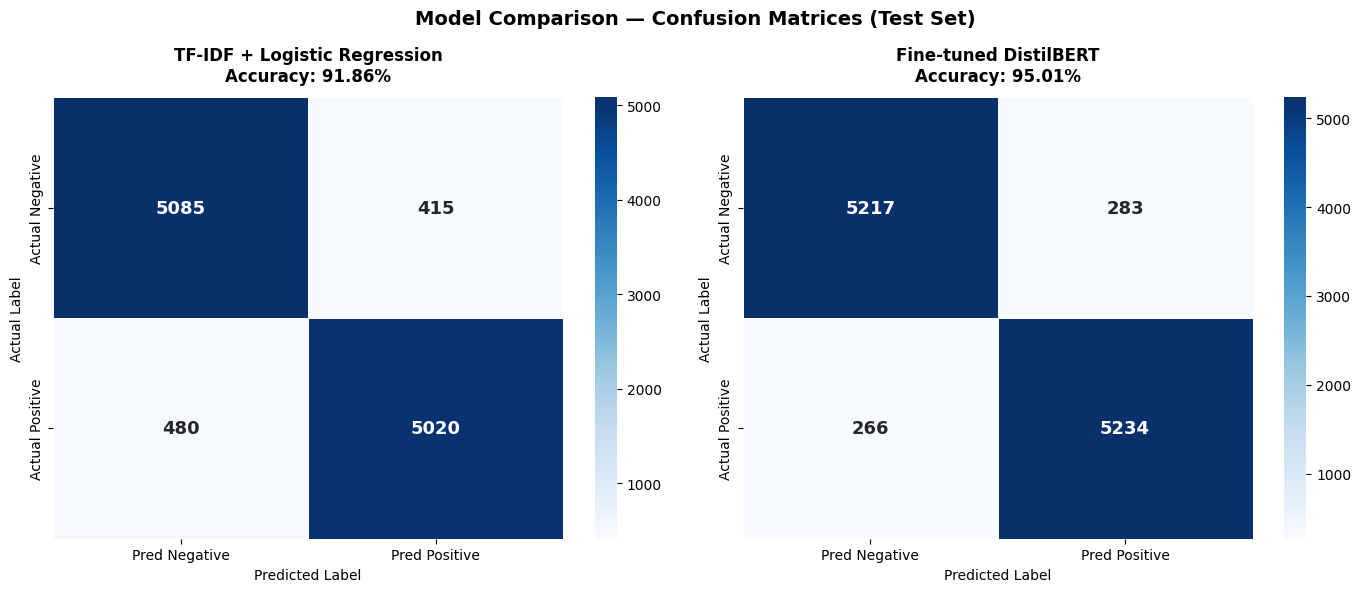

✅ Confusion matrix comparison saved


In [8]:
# ============================================================
# CONFUSION MATRIX — BOTH MODELS SIDE BY SIDE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_baseline    = confusion_matrix(y_test, y_pred_baseline)
cm_distilbert  = confusion_matrix(all_labels, all_preds)

for ax, cm, title, acc in zip(
    axes,
    [cm_baseline, cm_distilbert],
    ['TF-IDF + Logistic Regression', 'Fine-tuned DistilBERT'],
    [baseline_metrics['accuracy'], distilbert_metrics['accuracy']]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Pred Negative', 'Pred Positive'],
        yticklabels=['Actual Negative', 'Actual Positive'],
        linewidths=0.5,
        ax=ax,
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(
        f'{title}\nAccuracy: {acc*100:.2f}%',
        fontsize=12,
        fontweight='bold',
        pad=12
    )
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.suptitle('Model Comparison — Confusion Matrices (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PATHS['assets'], 'model_comparison_confusion.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix comparison saved")

In [9]:
# ============================================================
# ERROR ANALYSIS — WHAT DID THE MODEL GET WRONG?
# ============================================================

# Add predictions back to dataframe for analysis
df_test = df_test.reset_index(drop=True)
df_test['distilbert_pred']       = all_preds
df_test['distilbert_pred_label'] = pd.Series(all_preds).map({1:'Positive', 0:'Negative'})
df_test['confidence']            = np.max(all_probs, axis=1)
df_test['prob_positive']         = all_probs[:, 1]
df_test['prob_negative']         = all_probs[:, 0]
df_test['correct']               = (df_test['distilbert_pred'] == df_test['sentiment'])

# Wrong predictions
df_errors = df_test[~df_test['correct']].copy()

print(f"Total test reviews   : {len(df_test):,}")
print(f"Correct predictions  : {df_test['correct'].sum():,}")
print(f"Wrong predictions    : {len(df_errors):,}")
print(f"Error rate           : {len(df_errors)/len(df_test)*100:.2f}%")

# False Negatives — model said Negative but was actually Positive
fn = df_errors[
    (df_errors['sentiment']==1) &
    (df_errors['distilbert_pred']==0)
].sort_values('confidence', ascending=False)

# False Positives — model said Positive but was actually Negative
fp = df_errors[
    (df_errors['sentiment']==0) &
    (df_errors['distilbert_pred']==1)
].sort_values('confidence', ascending=False)

print(f"\nFalse Negatives (actual Positive, predicted Negative): {len(fn):,}")
print(f"False Positives (actual Negative, predicted Positive): {len(fp):,}")

print("\n--- 3 MOST CONFIDENT FALSE NEGATIVES ---")
print("(Model was very sure it was Negative but it was actually Positive)")
for _, row in fn.head(3).iterrows():
    print(f"\nReview    : {row['cleaned_text'][:150]}...")
    print(f"True label: Positive (Score: {row['Score']})")
    print(f"Predicted : Negative  (confidence: {row['confidence']:.3f})")

print("\n--- 3 MOST CONFIDENT FALSE POSITIVES ---")
print("(Model was very sure it was Positive but it was actually Negative)")
for _, row in fp.head(3).iterrows():
    print(f"\nReview    : {row['cleaned_text'][:150]}...")
    print(f"True label: Negative (Score: {row['Score']})")
    print(f"Predicted : Positive  (confidence: {row['confidence']:.3f})")

Total test reviews   : 11,000
Correct predictions  : 10,451
Wrong predictions    : 549
Error rate           : 4.99%

False Negatives (actual Positive, predicted Negative): 266
False Positives (actual Negative, predicted Positive): 283

--- 3 MOST CONFIDENT FALSE NEGATIVES ---
(Model was very sure it was Negative but it was actually Positive)

Review    : My local stores have not been stocking Red Oval for a while and I ran across a review in the San Francisco Examiner that asserted that expert tasters ...
True label: Positive (Score: 5)
Predicted : Negative  (confidence: 0.999)

Review    : After having a half-inch diameter circle of this sauce, i felt the heat, so i had a warm ice tea (it was the only thing i could find) and threw up abo...
True label: Positive (Score: 5)
Predicted : Negative  (confidence: 0.999)

Review    : The taste of the onions in this first jar is not up to the standards I've come to expect with my many jars that I have purchased through the years....
True label

In [10]:
# ============================================================
# SAVE FINAL METRICS TO FILE
# ============================================================

metrics_path = os.path.join('..', 'models', 'distilbert', 'test_metrics.txt')

with open(metrics_path, 'w') as f:
    f.write("FINE-TUNED DISTILBERT — FINAL TEST METRICS\n")
    f.write("=" * 50 + "\n")
    f.write(f"Accuracy  : {distilbert_metrics['accuracy']:.4f}\n")
    f.write(f"Precision : {distilbert_metrics['precision']:.4f}\n")
    f.write(f"Recall    : {distilbert_metrics['recall']:.4f}\n")
    f.write(f"F1-Score  : {distilbert_metrics['f1']:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(all_labels, all_preds,
            target_names=['Negative', 'Positive']))
    f.write("\n\nBASELINE COMPARISON\n")
    f.write("=" * 50 + "\n")
    f.write(f"Baseline Accuracy : {baseline_metrics['accuracy']:.4f}\n")
    f.write(f"Baseline F1       : {baseline_metrics['f1']:.4f}\n")
    f.write(f"Improvement       : +{(distilbert_metrics['accuracy']-baseline_metrics['accuracy'])*100:.2f}%\n")

print(f"✅ Final metrics saved to {metrics_path}")

print(f"""
╔══════════════════════════════════════════════════════╗
║         PHASE 7 COMPLETE ✅                         ║
╠══════════════════════════════════════════════════════╣
║  DistilBERT evaluated on unseen test set            ║
║  Full metrics generated                             ║
║  Model comparison complete                          ║
║  Error analysis done                                ║
║                                                      ║
║  NEXT: Build inference pipeline (src/inference.py)  ║
║  Then: Build Streamlit app (app/app.py)             ║
╚══════════════════════════════════════════════════════╝
""")

✅ Final metrics saved to ..\models\distilbert\test_metrics.txt

╔══════════════════════════════════════════════════════╗
║         PHASE 7 COMPLETE ✅                         ║
╠══════════════════════════════════════════════════════╣
║  DistilBERT evaluated on unseen test set            ║
║  Full metrics generated                             ║
║  Model comparison complete                          ║
║  Error analysis done                                ║
║                                                      ║
║  NEXT: Build inference pipeline (src/inference.py)  ║
║  Then: Build Streamlit app (app/app.py)             ║
╚══════════════════════════════════════════════════════╝

